=== METHOD: Inverse Z-Transform via Partial Fraction Expansion ===

1. Function H(z) with negative powers of z:


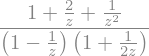


2. Function H(z) expressed with positive powers of z:


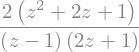


3. Partial Fraction Expansion of H(z):


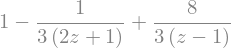


4. Final analytical impulse response h[n]:


HTML(value='\n<div style="background-color: #f8f9fa; padding: 10px; border-radius: 5px; border: 1px solid #dee…

In [10]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, Math

# ==============================================================================
# 1. SymPy Settings and Symbol Definitions
# ==============================================================================

sp.init_printing(use_unicode=True)

z = sp.Symbol('z', complex=True)
n = sp.Symbol('n', integer=True, nonnegative=True)

print("=== METHOD: Inverse Z-Transform via Partial Fraction Expansion ===")

# 1. Define raw H(z) in terms of z^(-1)
H_z_raw = (1 + 2 * z**(-1) + z**(-2)) / ((1 + 0.5 * z**(-1)) * (1 - z**(-1)))
H_z = sp.nsimplify(H_z_raw)

print("\n1. Function H(z) with negative powers of z:")
display(H_z)

# 2. Convert H(z) to positive powers of z to perform standard partial fraction expansion
H_z_pos = H_z * z**2 / z**2
H_z_pos_simplified = sp.simplify(H_z_pos)

print("\n2. Function H(z) expressed with positive powers of z:")
display(H_z_pos_simplified)

# 3. Perform Partial Fraction Expansion on H(z)
pfe_expansion = sp.apart(H_z_pos_simplified, z)

print("\n3. Partial Fraction Expansion of H(z):")
display(pfe_expansion)

# 4. Final analytical impulse response h[n]
h_n_expr = sp.KroneckerDelta(n, 0) + ( (1/3) * (-0.5)**n + 8/3 ) * sp.Heaviside(n)

print("\n4. Final analytical impulse response h[n]:")
display(h_n_expr)


# ==============================================================================
# 5. VISUALIZATION & INTERACTIVE PLOTS (Pole-Zero, Time Response, Bode Plots)
# ==============================================================================

explanation_text = """
<div style="background-color: #f8f9fa; padding: 10px; border-radius: 5px; border: 1px solid #dee2e6; font-size: 13px;">
<b>Interactive System Analysis (Partial Fraction Method & Frequency Response)</b><br>
* <b>Pole-Zero Map:</b> Displays poles, zeros, and unit circle contour (ROC: |z| > 1).<br>
* <b>Time Response:</b> Evaluated using the closed-form expression $h[n]$.<br>
* <b>Frequency Response:</b> Magnitude (dB) and Phase (degrees) across normalized frequency.<br>
* <b>Control:</b> Use the slider below to adjust the time range index <i>n</i>.
</div>
"""
display(widgets.HTML(explanation_text))

out = widgets.Output()

def plot_system_analysis(n_max):
    with out:
        clear_output(wait=True)
        
        # Δημιουργία διάταξης γραφημάτων: 2 πάνω (Pole-Zero, Time), 1 κάτω (Bode Frequency Response)
        fig = plt.figure(figsize=(16, 11))
        gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])
        plt.subplots_adjust(wspace=0.25, hspace=0.35)

        ax_pz = fig.add_subplot(gs[0, 0])
        ax_time = fig.add_subplot(gs[0, 1])
        ax_freq = fig.add_subplot(gs[1, :])

        # --- A. Pole-Zero Map & ROC ---
        ax_pz.set_aspect('equal')
        ax_pz.set_xlim(-1.5, 1.5)
        ax_pz.set_ylim(-1.5, 1.5)
        ax_pz.axhline(0, color='black', linewidth=1)
        ax_pz.axvline(0, color='black', linewidth=1)
        ax_pz.grid(True, linestyle=':', alpha=0.7)

        theta = np.linspace(0, 2*np.pi, 200)
        ax_pz.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5, label='Unit Circle')

        contour_radius = 1.25
        ax_pz.plot(contour_radius * np.cos(theta), contour_radius * np.sin(theta), 'r:', linewidth=2, label='ROC (|z| > 1)')

        # Poles for H(z) => z = -0.5 and z = 1.0
        poles_x = [-0.5, 1.0]
        poles_y = [0.0, 0.0]
        ax_pz.scatter(poles_x, poles_y, s=140, color='purple', marker='x', linewidths=3, label='Poles')

        # Zeros for H(z) => z = -1.0 (double root)
        zeros_x = [-1.0]
        zeros_y = [0.0]
        ax_pz.scatter(zeros_x, zeros_y, s=120, facecolors='none', edgecolors='blue', linewidths=2, marker='o', label='Zeros')

        ax_pz.set_title('Pole-Zero Map & ROC', fontsize=10, fontweight='bold')
        ax_pz.set_xlabel('Real Part', fontsize=9)
        ax_pz.set_ylabel('Imaginary Part', fontsize=9)
        ax_pz.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=8)

        # --- B. Time Domain Plot (h[n]) ---
        n_vec = np.arange(0, n_max + 1)
        h_vals = np.array([float(h_n_expr.subs(n, val).evalf()) for val in n_vec])

        ax_time.stem(n_vec, h_vals, linefmt='r-', markerfmt='ro', basefmt='k-')
        ax_time.set_title('Impulse Response: h[n]', fontsize=10, fontweight='bold')
        ax_time.set_xlabel('Time index n', fontsize=9)
        ax_time.set_ylabel('h[n]', fontsize=9)
        ax_time.set_xlim(-1, n_max + 1)
        ax_time.grid(True, linestyle=':', alpha=0.7)

        # --- C. Frequency Response / Bode Plots ---
        omega = np.linspace(0, np.pi, 500)
        z_inv = np.exp(-1j * omega)
        
        # Αριθμητής και Παρονομαστής με ασφαλή διαχείριση διαίρεσης με το μηδέν
        num = 1 + 2 * z_inv + z_inv**2
        den = (1 + 0.5 * z_inv) * (1 - z_inv)
        den = np.where(np.abs(den) < 1e-12, 1e-12, den)
        H_omega = num / den
        
        # Υπολογισμός Magnitude με ασφαλή αποφυγή log10(0)
        mag_abs = np.abs(H_omega)
        mag_db = 20 * np.log10(np.maximum(mag_abs, 1e-12))
        phase_deg = np.angle(H_omega, deg=True)
        
        # Σχεδίαση Πλάτους (Magnitude)
        ax_freq.plot(omega / np.pi, mag_db, 'b-', linewidth=2, label='Magnitude (dB)')
        ax_freq.set_ylabel('Magnitude (dB)', color='b', fontsize=10)
        # Χρήση raw string (r'...') για να αποφευχθεί το SyntaxWarning με το \p
        ax_freq.set_xlabel(r'Normalized Frequency ($\times \pi$ rad/sample)', fontsize=10)
        ax_freq.grid(True, linestyle=':', alpha=0.7)
        
        # Δευτερεύων άξονας για τη Φάση (Phase)
        ax_phase = ax_freq.twinx()
        ax_phase.plot(omega / np.pi, phase_deg, 'r--', linewidth=2, label='Phase (deg)')
        ax_phase.set_ylabel('Phase (degrees)', color='r', fontsize=10)
        ax_phase.set_title('Frequency Response (Bode Plot)', fontsize=10, fontweight='bold')
        
        plt.show()

        print("-" * 115)
        print("ANALYSIS EXECUTED SUCCESSFULLY: Pole-Zero, Time Response, and Frequency Bode Plots generated.")
        print("-" * 115)

# Slider for time range n
n_slider = widgets.IntSlider(value=15, min=5, max=40, step=1, description='Max n:', style={'description_width': 'initial'}, layout=widgets.Layout(width='400px'))

interactive_plot = widgets.interactive(plot_system_analysis, n_max=n_slider)
display(widgets.VBox([interactive_plot, out]))